**Program No. 21.  >> Intrusion Detection Visualization**

**Objective:** To analyze intrusion detection logs.

**Tasks:**
- Design intrusion detection log visualization
- Highlight possible attacks

**Outcome:** Students will understand visualization in cybersecurity.


**Step 1:** Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

**Step 2:** Load and Prepare Dataset

In [2]:
df = pd.read_csv("firewall_logs.csv")
df.columns = df.columns.str.strip()

# Convert timestamp
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

# Extract Hour
df["Hour"] = df["Timestamp"].dt.hour

print(df.head())

            Timestamp       Source_IP  Destination_IP Protocol  Source_Port  \
0 2025-01-25 21:37:13   35.118.190.14   44.207.46.184      UDP        25152   
1 2025-01-15 12:25:33  239.197.64.143   16.187.153.91      TCP        64772   
2 2025-01-15 02:26:55  162.58.193.198  154.214.181.40      UDP        24505   
3 2025-01-16 08:51:48  36.144.120.234  109.64.209.130      TCP        64576   
4 2025-01-30 16:59:33  167.162.40.243  115.93.100.100      UDP        16537   

   Destination_Port Action Threat_Level  Hour  
0                80  BLOCK       Medium    21  
1               443  BLOCK          Low    12  
2               443  BLOCK          Low     2  
3                80  BLOCK         High     8  
4                22  BLOCK         High    16  


**Visualization 1** — Attack Traffic Over Time

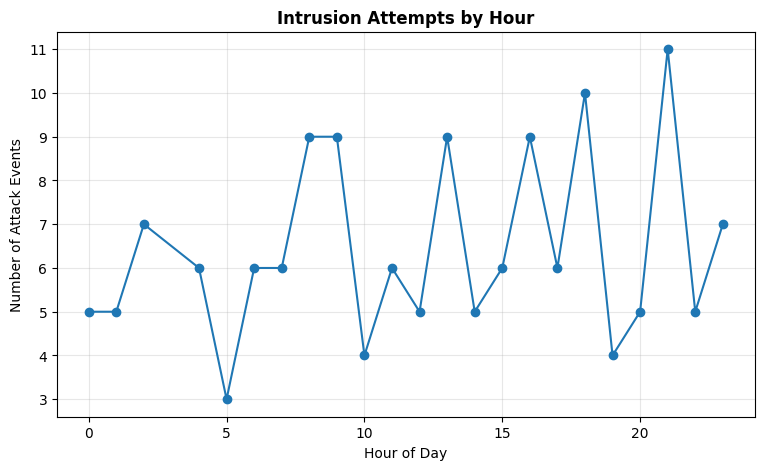

In [3]:
attack_df = df[df["Action"].isin(["BLOCK", "DROP"])]

hourly_attacks = attack_df.groupby("Hour").size()

plt.figure(figsize=(9,5))
plt.plot(hourly_attacks.index,
         hourly_attacks.values,
         marker='o')

plt.title("Intrusion Attempts by Hour",
          fontweight="bold")

plt.xlabel("Hour of Day")
plt.ylabel("Number of Attack Events")

plt.grid(alpha=0.3)
plt.show()

**Visualization 2** — High Threat Level Distribution

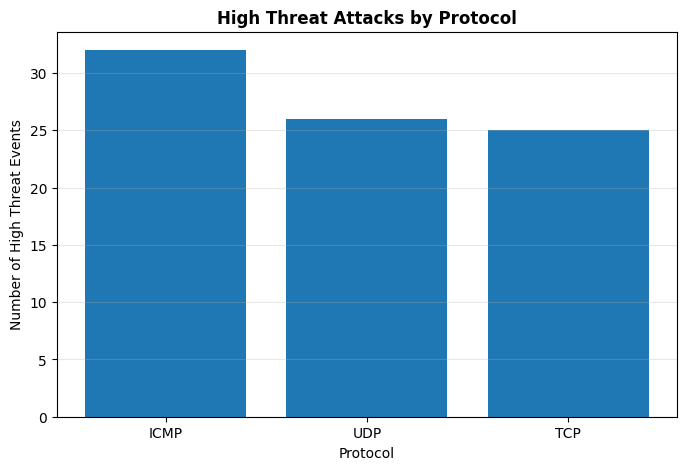

In [4]:
high_threat = df[df["Threat_Level"] == "High"]

threat_count = high_threat["Protocol"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(threat_count.index, threat_count.values)

plt.title("High Threat Attacks by Protocol",
          fontweight="bold")

plt.xlabel("Protocol")
plt.ylabel("Number of High Threat Events")

plt.grid(axis="y", alpha=0.3)
plt.show()

**Visualization 3** — Top Suspicious Source IPs

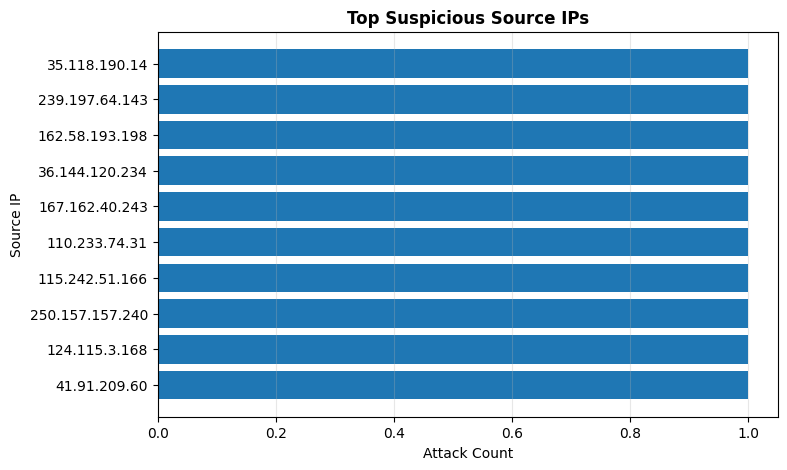

In [5]:
suspicious_ips = attack_df["Source_IP"].value_counts().head(10)

plt.figure(figsize=(8,5))
plt.barh(suspicious_ips.index,
         suspicious_ips.values)

plt.title("Top Suspicious Source IPs",
          fontweight="bold")

plt.xlabel("Attack Count")
plt.ylabel("Source IP")

plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()

**Visualization 4** — Targeted Destination Ports

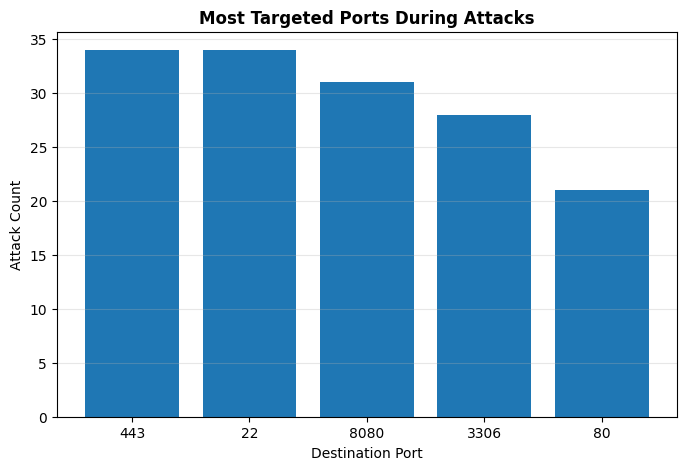

In [6]:
target_ports = attack_df["Destination_Port"].value_counts().head(10)

plt.figure(figsize=(8,5))
plt.bar(target_ports.index.astype(str),
        target_ports.values)

plt.title("Most Targeted Ports During Attacks",
          fontweight="bold")

plt.xlabel("Destination Port")
plt.ylabel("Attack Count")

plt.grid(axis="y", alpha=0.3)
plt.show()

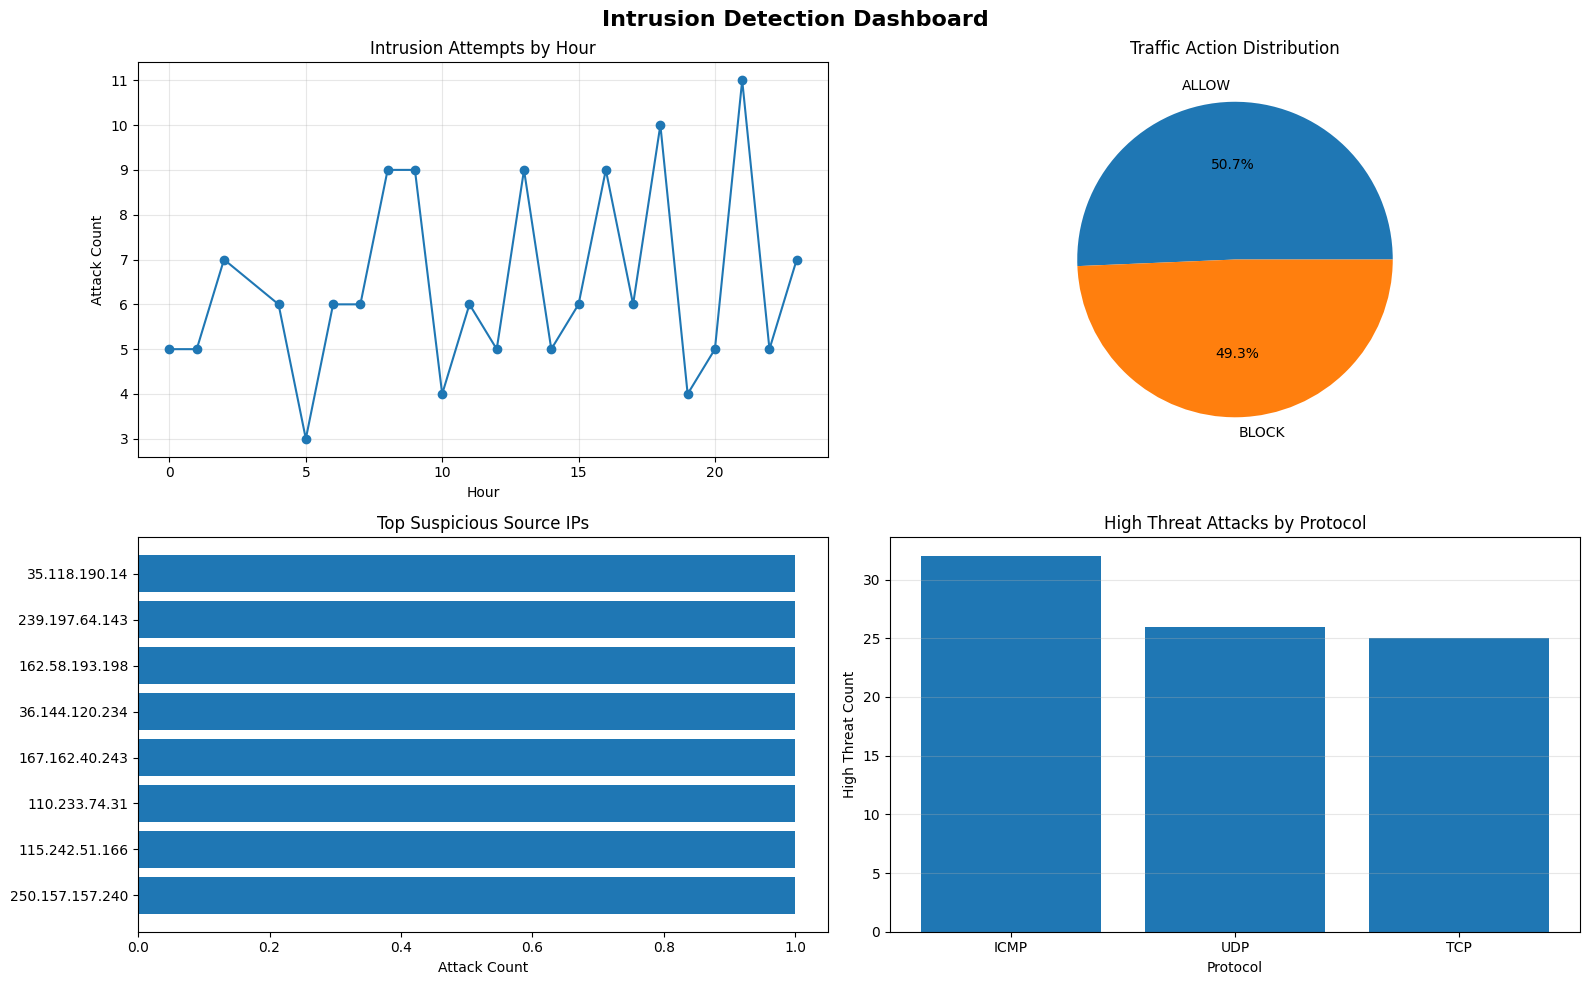

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("firewall_logs.csv")
df.columns = df.columns.str.strip()

# Convert timestamp
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["Hour"] = df["Timestamp"].dt.hour

# Filter attack traffic
attack_df = df[df["Action"].isin(["BLOCK", "DROP"])]

# Create dashboard
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Intrusion Detection Dashboard", fontsize=16, fontweight="bold")


# 1️⃣ Attack Traffic by Hour
hourly_attacks = attack_df.groupby("Hour").size()

axs[0,0].plot(hourly_attacks.index,
              hourly_attacks.values,
              marker='o')

axs[0,0].set_title("Intrusion Attempts by Hour")
axs[0,0].set_xlabel("Hour")
axs[0,0].set_ylabel("Attack Count")
axs[0,0].grid(alpha=0.3)


# 2️⃣ Action Distribution
action_counts = df["Action"].value_counts()

axs[0,1].pie(action_counts,
             labels=action_counts.index,
             autopct="%1.1f%%")

axs[0,1].set_title("Traffic Action Distribution")


# 3️⃣ Top Suspicious Source IPs
top_ips = attack_df["Source_IP"].value_counts().head(8)

axs[1,0].barh(top_ips.index, top_ips.values)

axs[1,0].set_title("Top Suspicious Source IPs")
axs[1,0].set_xlabel("Attack Count")
axs[1,0].invert_yaxis()


# 4️⃣ High Threat Protocol Analysis
high_threat = df[df["Threat_Level"] == "High"]
protocol_threat = high_threat["Protocol"].value_counts()

axs[1,1].bar(protocol_threat.index,
             protocol_threat.values)

axs[1,1].set_title("High Threat Attacks by Protocol")
axs[1,1].set_xlabel("Protocol")
axs[1,1].set_ylabel("High Threat Count")
axs[1,1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()